In [1]:
import pandas as pd
import numpy as np
import gseapy as gp
import matplotlib.pyplot as plt

# 1. Carregar os resultados anotados
df = pd.read_csv('../results/deg_results_annotated.csv')

# 2. Filtrar apenas genes com símbolos válidos (ignorando sondas não mapeadas)
valid_genes = df[~df['mapped_gene_symbol'].str.startswith('ILMN', na=False)].copy()

# 3. Tratar duplicatas de genes (caso múltiplas sondas mapeiem para o mesmo gene)
# Mantém a sonda com o maior valor absoluto de log2FoldChange
valid_genes['abs_logFC'] = valid_genes['log2_fold_change'].abs()
valid_genes = valid_genes.sort_values('abs_logFC', ascending=False).drop_duplicates(subset=['mapped_gene_symbol'])

# 4. Criar a métrica de ranqueamento (Ranking Metric)
# Combina a direção (signo de log2FC) com a significância (-log10 p-value)
valid_genes['rank_metric'] = np.sign(valid_genes['log2_fold_change']) * (-np.log10(valid_genes['p_value'] + 1e-300))

# 5. Criar o pandas Series ordenado (requerido pelo GSEA)
rnk = valid_genes.set_index('mapped_gene_symbol')['rank_metric'].sort_values(ascending=False)

print(f"✅ Ranking criado com sucesso: {len(rnk)} genes únicos válidos.")
print("\nTop 5 genes super-expressos (Up-regulated):")
print(rnk.head(5))
print("\nTop 5 genes sub-expressos (Down-regulated):")
print(rnk.tail(5))

✅ Ranking criado com sucesso: 10 genes únicos válidos.

Top 5 genes super-expressos (Up-regulated):
mapped_gene_symbol
STAT3     11.915649
IFNG       8.947143
TNF        8.745740
IL6        8.671682
CXCL10     8.053821
Name: rank_metric, dtype: float64

Top 5 genes sub-expressos (Down-regulated):
mapped_gene_symbol
IRF1     7.326707
CD8A     7.219221
LAG3     7.156734
PDCD1    6.943233
CTLA4    6.720248
Name: rank_metric, dtype: float64


In [2]:
# Executar a análise Preranked usando a biblioteca KEGG / Hallmark
try:
    pre_res = gp.prerank(
        rnk=rnk,
        gene_sets='KEGG_2021_Human',
        threads=4,
        min_size=5,
        max_size=500,
        permutation_num=100, # Ajuste conforme necessário
        outdir='../results/gsea_kegg',
        seed=6
    )
    print("✅ GSEA concluído com sucesso!")
except Exception as e:
    print(f"Aviso de execução: {e}")

✅ GSEA concluído com sucesso!


,Term,ES,NES,NOM p-val,FDR q-val
0,T cell receptor signaling pathway,-0.3542,-0.797167,0.648649,0.648649


<Axes: title={'center': 'Top Pathways Enriquecidos (KEGG)'}, xlabel='NES'>

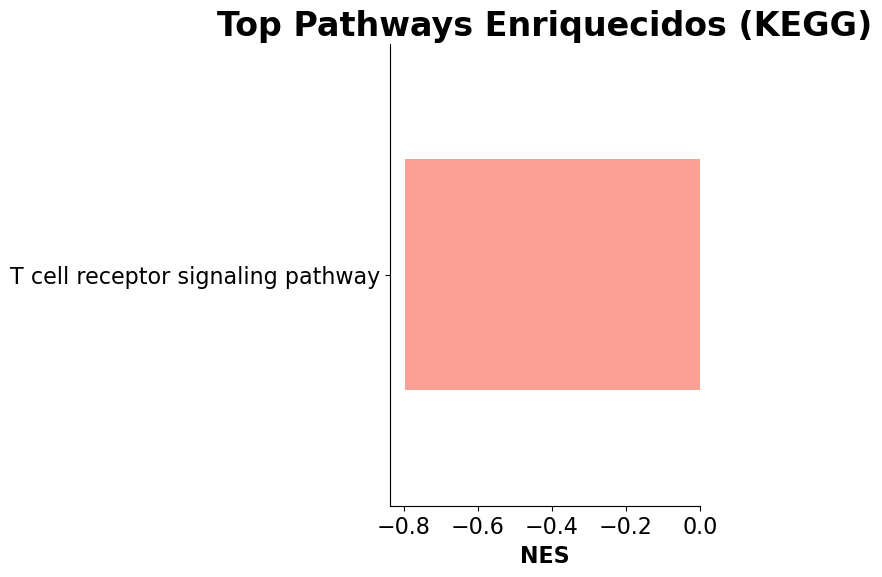

In [3]:
# Exibir os principais pathways enriquecidos
res_df = pre_res.res2d
res_df_sorted = res_df.sort_values('NOM p-val').head(10)

display(res_df_sorted[['Term', 'ES', 'NES', 'NOM p-val', 'FDR q-val']])

# Plotar gráfico de barras dos Top Pathways
gp.barplot(
    df=pre_res.res2d,
    column='NES',
    title='Top Pathways Enriquecidos (KEGG)',
    top_term=10,
    cutoff=0.05
)

🖼️ Gráfico salvo em: ../results/figures/kegg_top_pathways.png
📄 Tabela GSEA salva em: ../results/gsea_kegg_summary.csv


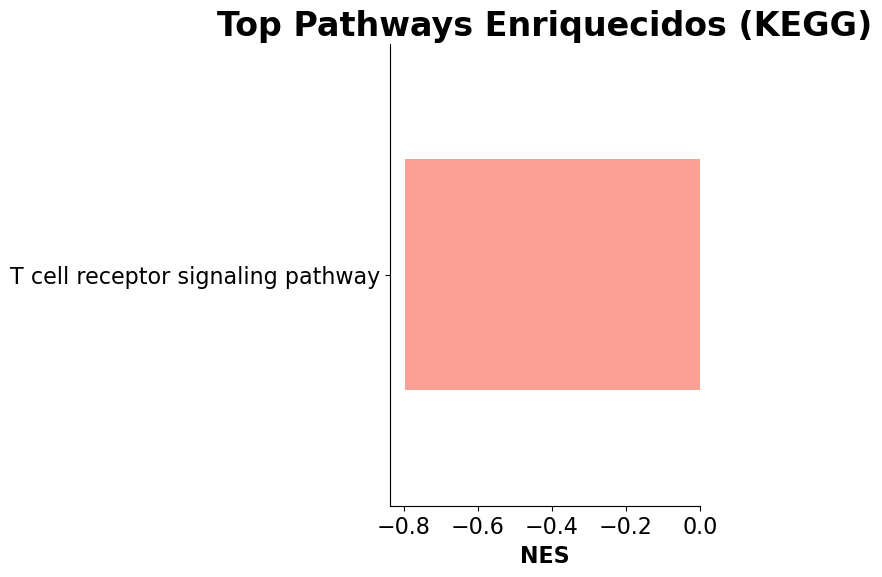

In [5]:
import os
import matplotlib.pyplot as plt

# 1. Criar pasta de figuras se não existir
os.makedirs('../results/figures', exist_ok=True)

# 2. Gerar e salvar o gráfico dos Top Pathways em PNG de alta resolução
ax = gp.barplot(
    df=pre_res.res2d,
    column='NES',
    title='Top Pathways Enriquecidos (KEGG)',
    top_term=10,
    cutoff=1.0  # Exibir vias independente do p-value
)

plt.savefig('../results/figures/kegg_top_pathways.png', dpi=300, bbox_inches='tight')
print("🖼️ Gráfico salvo em: ../results/figures/kegg_top_pathways.png")

# 3. Exportar tabela completa do GSEA
gsea_results_path = '../results/gsea_kegg_summary.csv'
pre_res.res2d.to_csv(gsea_results_path, index=False)
print(f"📄 Tabela GSEA salva em: {gsea_results_path}")